In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
from sklearn.preprocessing import PowerTransformer, StandardScaler


**Get Data from sources : Data warehouse**

In [8]:
rice_data = pd.read_csv("./data/data_warehouse/mdg_rice_data.csv")

**Overview of the data**

In [9]:
rice_data.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice,gasoline_price,diesel_price,kerosene_price,Phosphate rock,DAP,TSP,Urea,Potassium chloride
count,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000,3357.000000
mean,5465.691391,-23.326381,45.681308,68.020256,2719.932779,0.649053,5182.970807,4314.624665,2356.650581,205.743899,570.015903,502.204242,410.573871,446.281972
std,2966.248261,2.088586,1.394623,3.461633,561.773653,0.096432,899.903651,747.311161,149.333070,96.571988,141.108767,135.335625,173.985636,255.583771
min,732.000000,-25.530000,43.620000,64.000000,665.000000,0.210000,3640.000000,3000.000000,2130.000000,70.750000,263.000000,240.000000,186.250000,206.500000
25%,4617.000000,-24.480000,44.670000,64.000000,2450.000000,0.600000,4100.000000,3400.000000,2130.000000,147.500000,522.000000,447.500000,313.500000,292.500000
50%,6567.000000,-23.900000,45.440000,71.000000,2800.000000,0.650000,5900.000000,4900.000000,2430.000000,152.500000,568.330000,478.000000,352.000000,331.880000
75%,7199.000000,-23.290000,46.380000,71.000000,3150.000000,0.710000,5900.000000,4900.000000,2430.000000,320.000000,625.000000,555.000000,436.500000,508.750000
max,11282.000000,-12.280000,50.170000,71.000000,3850.000000,0.920000,5900.000000,4970.000000,2830.000000,347.500000,954.000000,856.000000,925.000000,1202.000000


**View Data distribution**

<Axes: xlabel='price', ylabel='Count'>

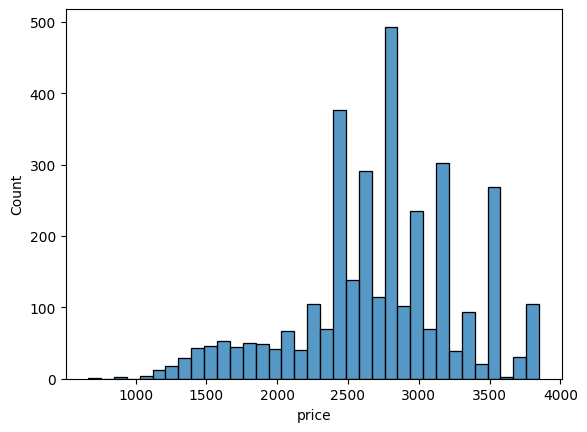

In [10]:
sns.histplot(rice_data["price"])

In [11]:
rice_data["price"].skew()

np.float64(-0.4312204653638156)

**Interpretations**
- The data description with `rice_data.describe()` shows that :  **mean("price") < mediane("price")**
- The histogram shows that the majority of the data is located on the right side of the histogram
- The value of the skewness is < -0.3

--> So the distribution of the rice price (the target) is left-skewed.
**So what ?** => Transformation needed for a more reliable model.

**Applied transformation**
- The transformation applied to the rice price data are:
    - **Box-Cox Transformation**
    - **Standardization (mean = 0, std-deviation = 1)**

In [12]:
pt = PowerTransformer(method="box-cox", standardize=True)
price_reshaped = rice_data["price"].to_numpy().reshape(-1, 1)
rice_data['price_transformed'] = pt.fit_transform(price_reshaped)

**Box-cox transfo compared with Normal distribution**

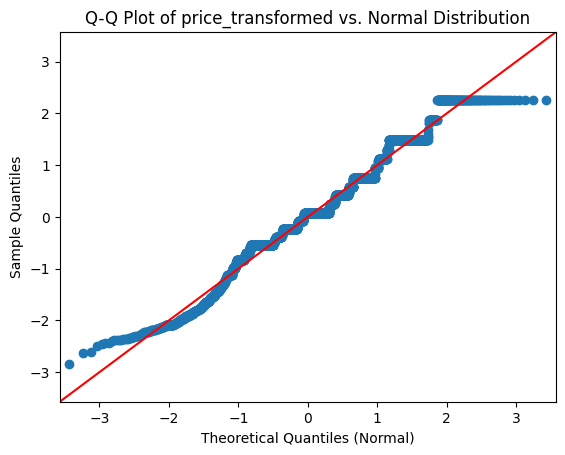

In [13]:
sm.qqplot(rice_data["price_transformed"], line='45', fit=True)

plt.title('Q-Q Plot of price_transformed vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles (Normal)')
plt.ylabel('Sample Quantiles')
plt.show()

**Square Transformation**

In [14]:
rice_data["price_squared"] = (rice_data["price"].to_numpy())**3

**Square Transformation compared with Normal distro**

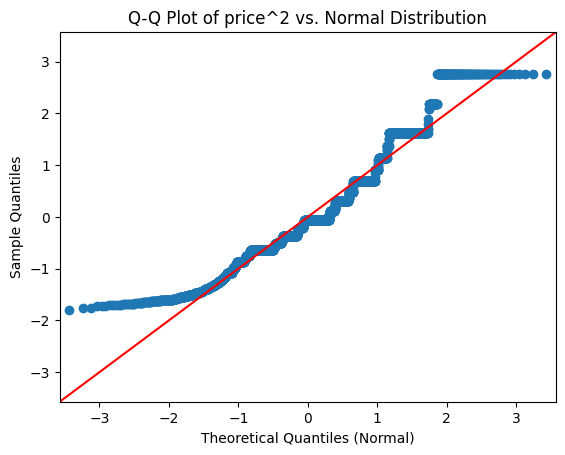

In [15]:
sm.qqplot(rice_data["price_squared"], line='45', fit=True)

plt.title('Q-Q Plot of price^2 vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles (Normal)')
plt.ylabel('Sample Quantiles')
plt.show()

**Reflexion method**

In [16]:
K = rice_data["price"].max() + 1
rice_data["price_reflected"] = np.sqrt(K - rice_data["price"].to_numpy())

<Axes: xlabel='price_reflected', ylabel='Count'>

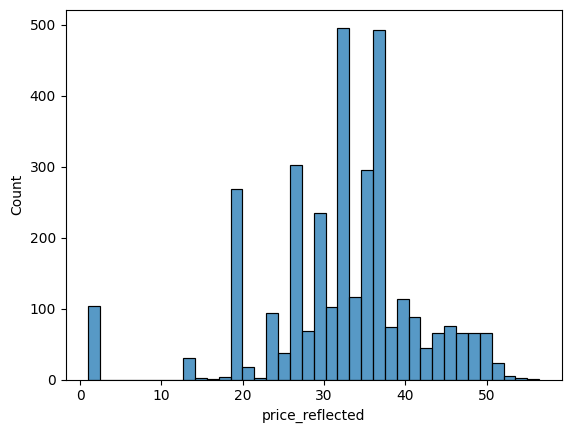

In [17]:
sns.histplot(rice_data["price_reflected"])

**Normalization**

In [18]:
scaler = StandardScaler()

rice_data['price_reflected'] = scaler.fit_transform(rice_data[['price_reflected']])

**Reflexion method compared with Normal distro**

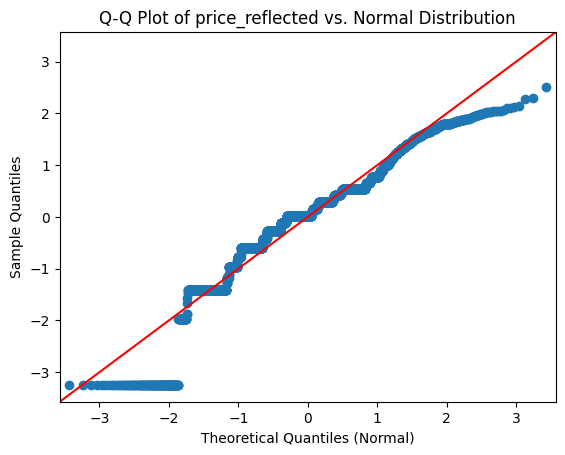

In [19]:
sm.qqplot(rice_data["price_reflected"], line='45', fit=True)

plt.title('Q-Q Plot of price_reflected vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles (Normal)')
plt.ylabel('Sample Quantiles')
plt.show()

**Skewness comparison**

In [20]:
print(rice_data["price_transformed"].skew()) # box-cox
print(rice_data["price_squared"].skew())
print(rice_data["price_reflected"].skew())

-0.02508180312040639
0.7363905695585387
-0.8824423282772889


The skewness of the feature "price_transformed" (**box-cox transformation**) is acceptable.

<Axes: xlabel='diesel_price', ylabel='Count'>

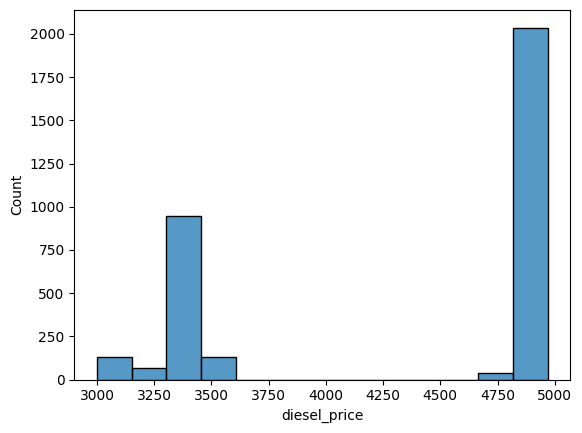

In [21]:
sns.histplot(rice_data["diesel_price"])

<Axes: xlabel='gasoline_price', ylabel='Count'>

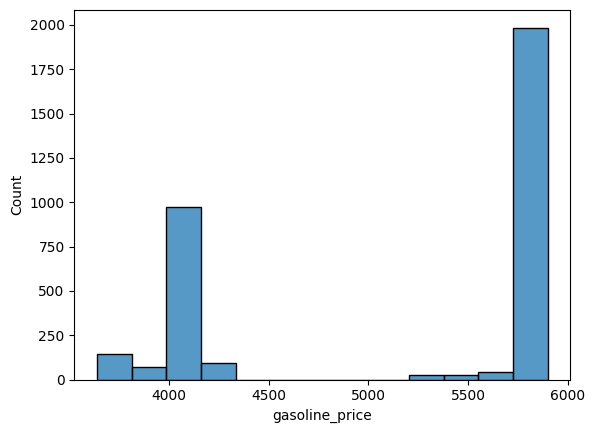

In [22]:
sns.histplot(rice_data["gasoline_price"])

In [23]:
currency_data = yf.download("USDMGA=X", start="2015-01-01", end="2026-03-24")

[*********************100%***********************]  1 of 1 completed


<Axes: ylabel='Count'>

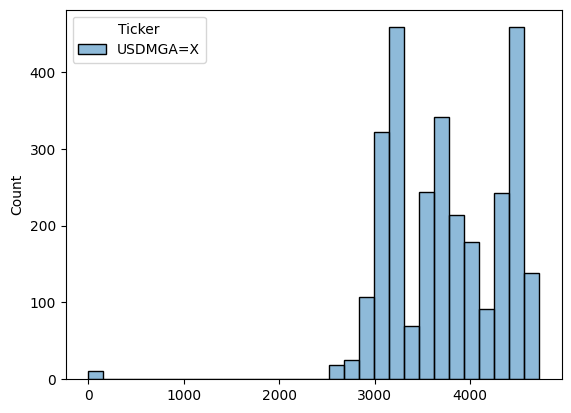

In [24]:
sns.histplot(currency_data["Close"])

<Axes: xlabel='Date'>

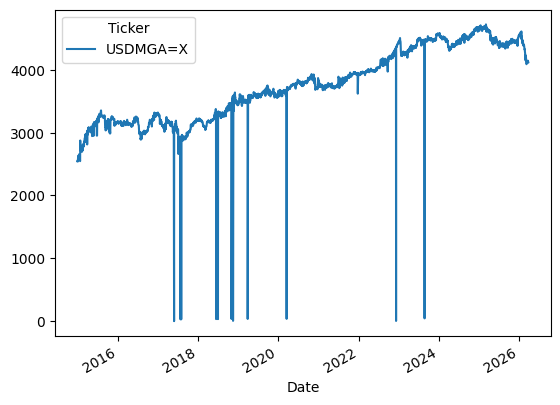

In [25]:
currency_data["Close"].plot()

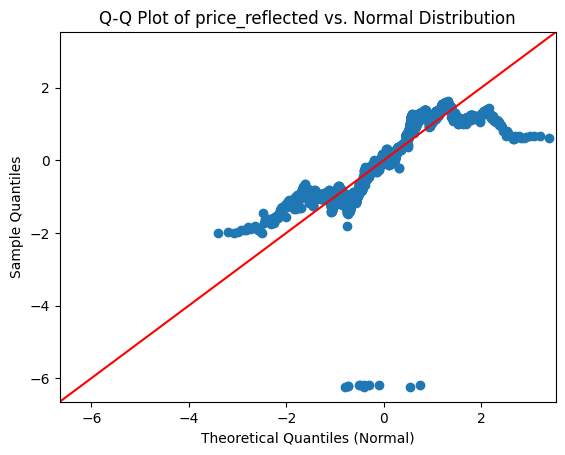

In [26]:
sm.qqplot(currency_data["Close"], line='45', fit=True)

plt.title('Q-Q Plot of price_reflected vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles (Normal)')
plt.ylabel('Sample Quantiles')
plt.show()

In [27]:
pt = PowerTransformer(method="box-cox", standardize=True)
price_reshaped = currency_data["Close"].to_numpy().reshape(-1, 1)
test = pt.fit_transform(price_reshaped)

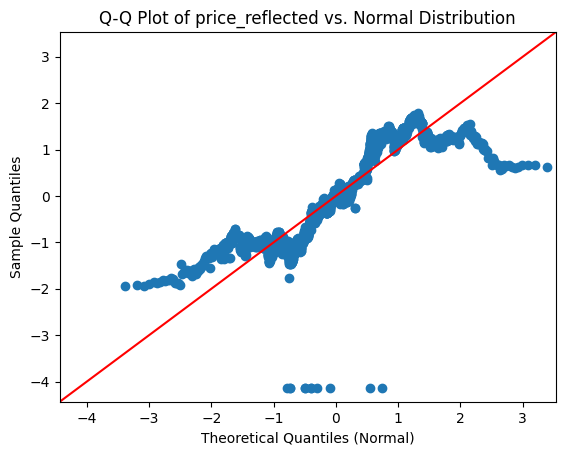

In [28]:
sm.qqplot(test, line='45', fit=True)

plt.title('Q-Q Plot of price_reflected vs. Normal Distribution')
plt.xlabel('Theoretical Quantiles (Normal)')
plt.ylabel('Sample Quantiles')
plt.show()